In [29]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import openmc
import openmc.stats

openmc.config['cross_sections'] = '/mnt/d/xs/openmc/endfb-vii.1-hdf5/cross_sections.xml'
RUN_DIR = pathlib.Path('test_source_position_outputs')
RUN_DIR.mkdir(exist_ok=True)
ALPHA = 0.05

In [30]:
X_MIN = -5.0
X_MAX = 5.0
Y_HALF = 0.05
Z_HALF = 0.05
X_PEAK = 1.0
N_X_BINS = 100


def triangular_pdf(x, x_min, x_peak, x_max):
    x = np.asarray(x)
    pdf = np.zeros_like(x, dtype=float)
    mask_left = (x >= x_min) & (x < x_peak)
    pdf[mask_left] = 2 * (x[mask_left] - x_min) / ((x_max - x_min) * (x_peak - x_min))
    mask_right = (x >= x_peak) & (x <= x_max)
    pdf[mask_right] = 2 * (x_max - x[mask_right]) / ((x_max - x_min) * (x_max - x_peak))
    return pdf


source_x_values = np.linspace(X_MIN, X_MAX, 201)
source_x_probs = triangular_pdf(source_x_values, X_MIN, X_PEAK, X_MAX)
x_dist = openmc.stats.Tabular(source_x_values, source_x_probs, interpolation='linear-linear')
y_dist = openmc.stats.Discrete([0.0], [1.0])
z_dist = openmc.stats.Discrete([-Z_HALF + 0.001], [1.0])
spatial_dist = openmc.stats.CartesianIndependent(x_dist, y_dist, z_dist)

In [31]:
openmc.reset_auto_ids()

x_min_surf = openmc.XPlane(X_MIN, boundary_type='vacuum')
x_max_surf = openmc.XPlane(X_MAX, boundary_type='vacuum')
y_min_surf = openmc.YPlane(-Y_HALF, boundary_type='vacuum')
y_max_surf = openmc.YPlane(Y_HALF, boundary_type='vacuum')
z_min_surf = openmc.ZPlane(-Z_HALF, boundary_type='vacuum')
z_max_surf = openmc.ZPlane(Z_HALF, boundary_type='vacuum')

region = +x_min_surf & -x_max_surf & +y_min_surf & -y_max_surf & +z_min_surf & -z_max_surf
vacuum_cell = openmc.Cell(name='vacuum', region=region)
universe = openmc.Universe(cells=[vacuum_cell])
geometry = openmc.Geometry(universe)

In [32]:
source = openmc.IndependentSource(
    space=spatial_dist,
    energy=openmc.stats.Discrete([14.0e6], [1.0]),
    angle=openmc.stats.Monodirectional([0.0, 0.0, 1.0]),
    particle='neutron',
    strength=1.0
)

In [33]:
mesh = openmc.RegularMesh()
mesh.dimension = [N_X_BINS, 1, 1]
mesh.lower_left = [X_MIN, -Y_HALF, -Z_HALF]
mesh.upper_right = [X_MAX, Y_HALF, Z_HALF]

position_tally = openmc.Tally(name='position_profile')
position_tally.filters = [openmc.MeshFilter(mesh)]
position_tally.scores = ['flux']
position_tally.higher_moments = True
tallies = openmc.Tallies([position_tally])

In [34]:
PARTICLES_PER_BATCH = 10000
N_BATCHES = 100
TOTAL_PARTICLES = PARTICLES_PER_BATCH * N_BATCHES

settings = openmc.Settings()
settings.run_mode = 'fixed source'
settings.particles = PARTICLES_PER_BATCH
settings.batches = N_BATCHES
settings.seed = 123
settings.source = source
settings.output = {'tallies': False}

In [35]:
model = openmc.Model(geometry=geometry, settings=settings, tallies=tallies)
model.export_to_model_xml(path=RUN_DIR)

In [36]:
sp_path = model.run(cwd=RUN_DIR, output=False)

In [37]:
with openmc.StatePoint(sp_path) as sp:
    tally = sp.get_tally(name='position_profile')
    tally_mean = tally.mean.flatten()
    tally_std = tally.std_dev.flatten()

x_profile_mean = tally_mean[:N_X_BINS]
x_profile_std = tally_std[:N_X_BINS]
x_bin_edges = np.linspace(X_MIN, X_MAX, N_X_BINS + 1)
x_bin_centers = 0.5 * (x_bin_edges[:-1] + x_bin_edges[1:])
x_bin_widths = np.diff(x_bin_edges)

total_flux = x_profile_mean.sum()
measured_pdf = x_profile_mean / (total_flux * x_bin_widths)
measured_pdf_std = x_profile_std / (total_flux * x_bin_widths)

In [38]:
expected_pdf = triangular_pdf(x_bin_centers, X_MIN, X_PEAK, X_MAX)
observed_fractions = x_profile_mean / x_profile_mean.sum()
expected_fractions = expected_pdf * x_bin_widths
expected_fractions /= expected_fractions.sum()
eff_sample_size = TOTAL_PARTICLES

In [39]:
z_95 = stats.norm.ppf(0.975)
ci_lower = measured_pdf - z_95 * measured_pdf_std
ci_upper = measured_pdf + z_95 * measured_pdf_std
within_ci = (expected_pdf >= ci_lower) & (expected_pdf <= ci_upper)
n_bins_valid = (expected_pdf > 0).sum()
ci_coverage = within_ci.sum() / n_bins_valid * 100

CI_PASS_THRESHOLD = 90.0
ci_test_pass = ci_coverage >= CI_PASS_THRESHOLD

In [40]:
min_expected_fraction = 0.001
valid_bins = expected_fractions > min_expected_fraction
n_valid_bins = valid_bins.sum()

chi2_contributions = np.zeros_like(observed_fractions)
chi2_contributions[valid_bins] = (
    (observed_fractions[valid_bins] - expected_fractions[valid_bins])**2
    / expected_fractions[valid_bins]
)
chi2_stat = eff_sample_size * chi2_contributions[valid_bins].sum()
dof = n_valid_bins - 1
chi2_pvalue = 1 - stats.chi2.cdf(chi2_stat, dof)
chi2_test_pass = chi2_pvalue > ALPHA

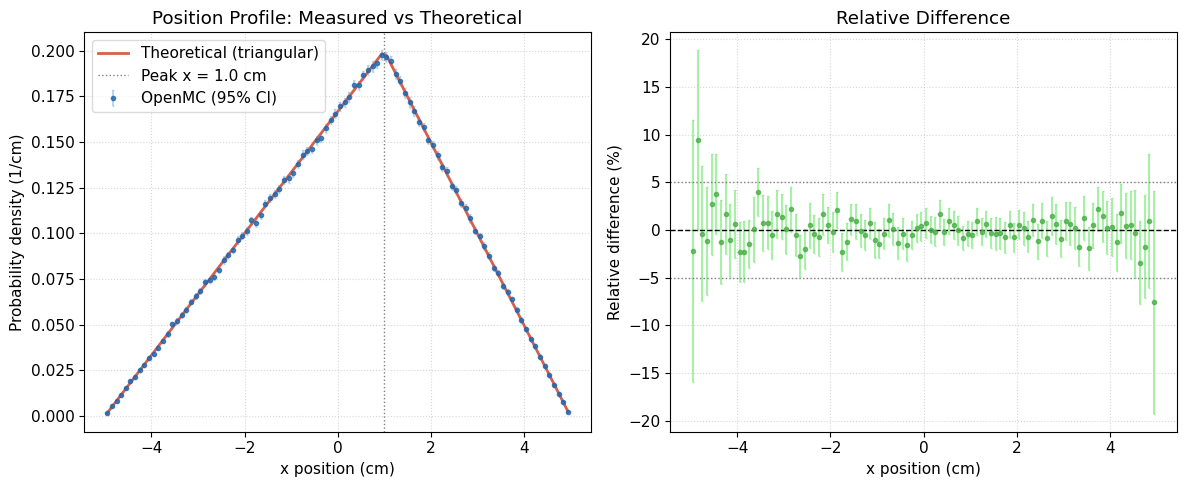

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.errorbar(x_bin_centers, measured_pdf,
            yerr=z_95 * measured_pdf_std,
            fmt='o', ms=3, color='#2166ac', ecolor='#a6cee3',
            capsize=1, label='OpenMC (95% CI)', alpha=0.8)
ax.plot(x_bin_centers, expected_pdf,
        '-', color='#d6604d', lw=2, label='Theoretical (triangular)')
ax.axvline(X_PEAK, color='gray', ls=':', lw=1, label=f'Peak x = {X_PEAK} cm')
ax.set_xlabel('x position (cm)')
ax.set_ylabel('Probability density (1/cm)')
ax.set_title('Position Profile: Simulated vs Theoretical')
ax.legend()
ax.grid(True, ls=':', alpha=0.5)

ax = axes[1]
with np.errstate(divide='ignore', invalid='ignore'):
    rel_diff = np.where(expected_pdf > 0,
                        (measured_pdf - expected_pdf) / expected_pdf * 100,
                        0)
    rel_diff_err = np.where(expected_pdf > 0,
                            measured_pdf_std / expected_pdf * 100,
                            0)

ax.errorbar(x_bin_centers, rel_diff,
            yerr=z_95 * rel_diff_err,
            fmt='o', ms=3, color='#4daf4a', ecolor='lightgreen',
            capsize=1, alpha=0.8)
ax.axhline(0, color='k', ls='--', lw=1)
ax.axhline(5, color='gray', ls=':', lw=1)
ax.axhline(-5, color='gray', ls=':', lw=1)
ax.set_xlabel('x position (cm)')
ax.set_ylabel('Relative difference (%)')
ax.set_title('Relative Difference')
ax.grid(True, ls=':', alpha=0.5)

fig.tight_layout()
plt.savefig('7224_ss_2.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
overall_pass = chi2_test_pass and ci_test_pass

In [43]:
result = 'PASS' if overall_pass else 'FAIL'
with open('results.txt', 'w') as results_file:
    results_file.write(result + '\n')